In [2]:
import torch
from torch import nn
from d2l import d2l_torch as d2l

In [3]:
batch_size = 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)

训练数据集已存在，直接读取...
测试数据集已存在，直接读取...


### 4.2.1 初始化模型参数

In [5]:
num_inputs, num_outputs, num_hiddens = 784, 10, 256

# 初始化参数W1: 形状为 [784, 256] 的，标准差为 0.01 的随机值
W1 = nn.Parameter(torch.randn(num_inputs, num_hiddens, requires_grad=True) * 0.01)
# 初始化偏置参数b1: 全为零的向量
b1 = nn.Parameter(torch.zeros(num_hiddens, requires_grad=True))

W2 = nn.Parameter(torch.randn(num_hiddens, num_outputs, requires_grad=True) * 0.01)
b2 = nn.Parameter(torch.zeros(num_outputs, requires_grad=True))

params = [W1, b1, W2, b2]

### 4.2.2 激活函数

In [6]:
def relu(X):
    a = torch.zeros_like(X)
    return torch.max(X, a)

### 4.2.3 模型

In [8]:
def net(X):
    X = X.reshape(-1, num_inputs)
    H = relu(X@W1 + b1)         # @代表矩阵乘法
    return H@W2 + b2

### 4.2.4 损失函数

In [10]:
# reduction参数的三种类型：
# none: 不聚合，返回每个样本的损失, 输出形状为(batch_size,)
# mean: 返回所有样本损失的平均值, 输出形状为标量
# sum: 返回所有样本损失的总和, 输出形状为标量
# 这里为什么用 none?
# 因为后续使用d2l.train_ch3()函数进行训练，这个函数中更新梯度时，会根据优化器的类型，选择使用损失函数的均值还是总和
# 因此这里不需要额外再计算均值或总和

loss = nn.CrossEntropyLoss(reduction='none')

### 4.2.5 训练

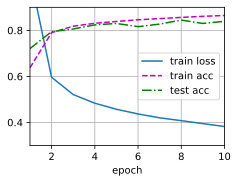

In [11]:
num_epochs, lr = 10, 0.1
updater = torch.optim.SGD(params, lr=lr, momentum=0.0, weight_decay=0.0)
d2l.train_ch3(net, train_iter, test_iter, loss, num_epochs, updater)

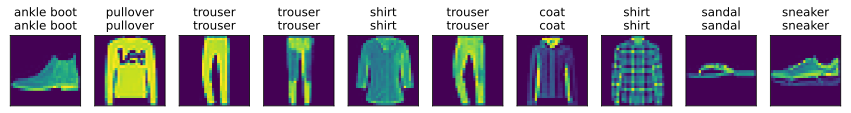

In [12]:
d2l.predict_ch3(net, test_iter)